In [2]:
import pandas as pd
import numpy as np
import os

In [8]:
data_files = {
    "CDs_and_Vinyl": "CDs_and_Vinyl.jsonl.gz",
    "Digital_Music": "Digital_Music.jsonl.gz",
    "Handmade_Products": "Handmade_Products.jsonl.gz",
    "Video_Games": "Video_Games.jsonl.gz"
}

In [12]:
df_test = pd.read_json("Video_Games.jsonl.gz", lines=True, compression="gzip")
df_test.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,4,It’s pretty sexual. Not my fav,I’m playing on ps5 and it’s interesting. It’s...,[],B07DJWBYKP,B07DK1H3H5,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2020-12-17 06:33:24.795,0,True
1,5,Good. A bit slow,Nostalgic fun. A bit slow. I hope they don’t...,[],B00ZS80PC2,B07SRWRH5D,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,2020-04-16 15:31:54.941,1,False
2,5,... an order for my kids & they have really en...,This was an order for my kids & they have real...,[],B01FEHJYUU,B07MFMFW34,AGXVBIUFLFGMVLATYXHJYL4A5Q7Q,2017-03-30 12:37:11.000,0,True
3,5,Great alt to pro controller,"These work great, They use batteries which is ...",[],B07GXJHRVK,B0BCHWZX95,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,2019-12-29 16:40:34.017,0,True
4,5,solid product,I would recommend to anyone looking to add jus...,[],B00HUWA45W,B00HUWA45W,AFTC6ZR5IKNRDG5JCPVNVMU3XV2Q,2015-03-29 01:18:52.000,0,True


In [14]:
df_test.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')

In [16]:
sample_size = 5000

dfs = []

for category, path in data_files.items():
    df = pd.read_json(path, lines=True, compression="gzip")
    df = df.sample(n=min(sample_size, len(df)), random_state=42)
    df["category"] = category
    dfs.append(df)

reviews_df = pd.concat(dfs, ignore_index=True)

In [18]:
reviews_df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category
0,5,Great Scott,Ok...am I missing something here? Scott Walker...,[],B0000019R2,B0000019R2,AEXKYJ25VORZRWYJ6WQHO7S33GRQ,2001-07-19 18:18:49.000,8,False,CDs_and_Vinyl
1,5,Still way ahead,"""When I was a little kid in La Jolla, Californ...",[],B000GRTQSE,B000GRTQSE,AE6KSWUK2VIFSXP7ZCVXM54CHXIQ,2006-09-03 10:14:36.000,11,False,CDs_and_Vinyl
2,4,Entertaining,"I generally dont get into screamo, but i would...",[],B000GIXHIS,B000GIXHIS,AFRJSYXMELWV2BPENXWC3XNMC6ZA,2006-08-29 09:54:45.000,0,False,CDs_and_Vinyl
3,4,I love it great background,I love it great background music,[],B00EQJ0VNC,B00EQJ0VNC,AHVYBZENFQXUGGVCPLI3JZMBE3XA,2015-06-24 04:02:36.000,1,True,CDs_and_Vinyl
4,3,Voices Drown by Music,The Alan Parsons Symphonic Project Live in Col...,[],B01D5KI7ME,B01D5KI7ME,AFLMZRV74ZVORT3K6JMQMMCB7XIA,2023-02-27 19:59:27.251,0,False,CDs_and_Vinyl


In [20]:
reviews_df.shape

(20000, 11)

In [22]:
reviews_df["category"].value_counts()

category
CDs_and_Vinyl        5000
Digital_Music        5000
Handmade_Products    5000
Video_Games          5000
Name: count, dtype: int64

In [24]:
reviews_df.columns.tolist()

['rating',
 'title',
 'text',
 'images',
 'asin',
 'parent_asin',
 'user_id',
 'timestamp',
 'helpful_vote',
 'verified_purchase',
 'category']

In [26]:
reviews_df = reviews_df[["title", "text", "rating", "category"]].copy()

reviews_df["title"] = reviews_df["title"].fillna("")
reviews_df["text"] = reviews_df["text"].fillna("")

reviews_df["review_text"] = reviews_df["title"] + " " + reviews_df["text"]

reviews_df.head()

,title,text,rating,category,review_text
0,Great Scott,Ok...am I missing something here? Scott Walker...,5,CDs_and_Vinyl,Great Scott Ok...am I missing something here? ...
1,Still way ahead,"""When I was a little kid in La Jolla, Californ...",5,CDs_and_Vinyl,"Still way ahead ""When I was a little kid in La..."
2,Entertaining,"I generally dont get into screamo, but i would...",4,CDs_and_Vinyl,Entertaining I generally dont get into screamo...
3,I love it great background,I love it great background music,4,CDs_and_Vinyl,I love it great background I love it great ba...
4,Voices Drown by Music,The Alan Parsons Symphonic Project Live in Col...,3,CDs_and_Vinyl,Voices Drown by Music The Alan Parsons Symphon...


In [28]:
reviews_df["rating"].value_counts().sort_index()

rating
1     1384
2      691
3     1160
4     2205
5    14560
Name: count, dtype: int64

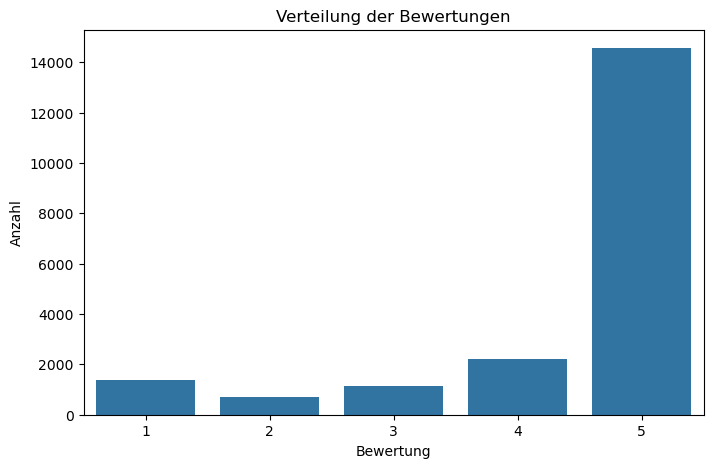

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=reviews_df, x="rating")
plt.title("Verteilung der Bewertungen")
plt.xlabel("Bewertung")
plt.ylabel("Anzahl")
plt.show()

In [34]:
from sklearn.model_selection import train_test_split

X = reviews_df["review_text"]
y = reviews_df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

Trainingsdaten: (16000,)
Testdaten: (4000,)


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=10000)),
    ("clf", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7645


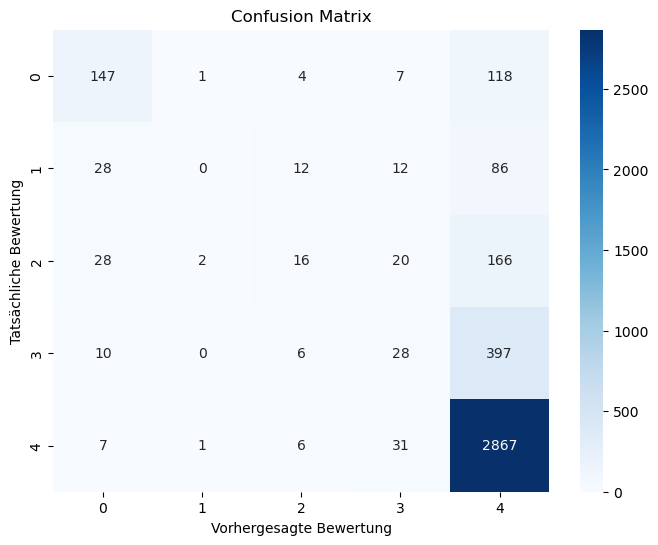

In [38]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Vorhergesagte Bewertung")
plt.ylabel("Tatsächliche Bewertung")
plt.show()

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.67      0.53      0.59       277
           2       0.00      0.00      0.00       138
           3       0.36      0.07      0.12       232
           4       0.29      0.06      0.10       441
           5       0.79      0.98      0.88      2912

    accuracy                           0.76      4000
   macro avg       0.42      0.33      0.34      4000
weighted avg       0.67      0.76      0.70      4000



In [42]:
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.7645
              precision    recall  f1-score   support

           1       0.67      0.53      0.59       277
           2       0.00      0.00      0.00       138
           3       0.36      0.07      0.12       232
           4       0.29      0.06      0.10       441
           5       0.79      0.98      0.88      2912

    accuracy                           0.76      4000
   macro avg       0.42      0.33      0.34      4000
weighted avg       0.67      0.76      0.70      4000



In [44]:
from sklearn.naive_bayes import MultinomialNB

nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=10000)),
    ("clf", MultinomialNB())
])

nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", accuracy_nb)

Naive Bayes Accuracy: 0.73125


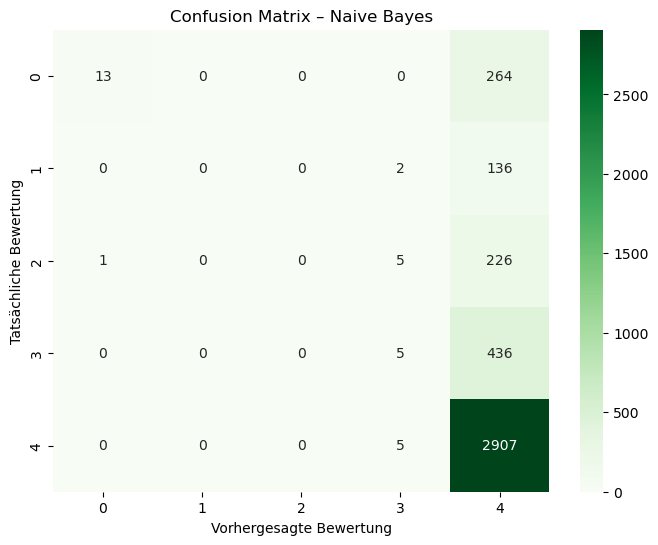

In [46]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8,6))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix – Naive Bayes")
plt.xlabel("Vorhergesagte Bewertung")
plt.ylabel("Tatsächliche Bewertung")
plt.show()

In [48]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [accuracy, accuracy_nb]
})

results

,Model,Accuracy
0,Logistic Regression,0.76450
1,Naive Bayes,0.73125


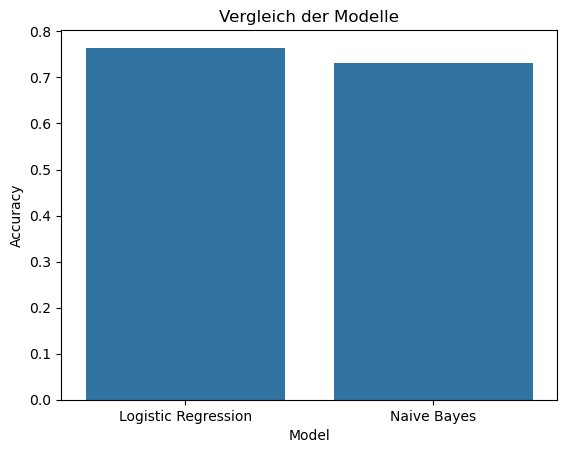

In [50]:
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Vergleich der Modelle")
plt.show()

In [52]:
reviews_df.groupby("category")["rating"].mean()

category
CDs_and_Vinyl        4.5044
Digital_Music        4.5178
Handmade_Products    4.4838
Video_Games          4.0672
Name: rating, dtype: float64

In [60]:
!pip install wordcloud

In [62]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [64]:
all_text = " ".join(reviews_df["review_text"].astype(str))

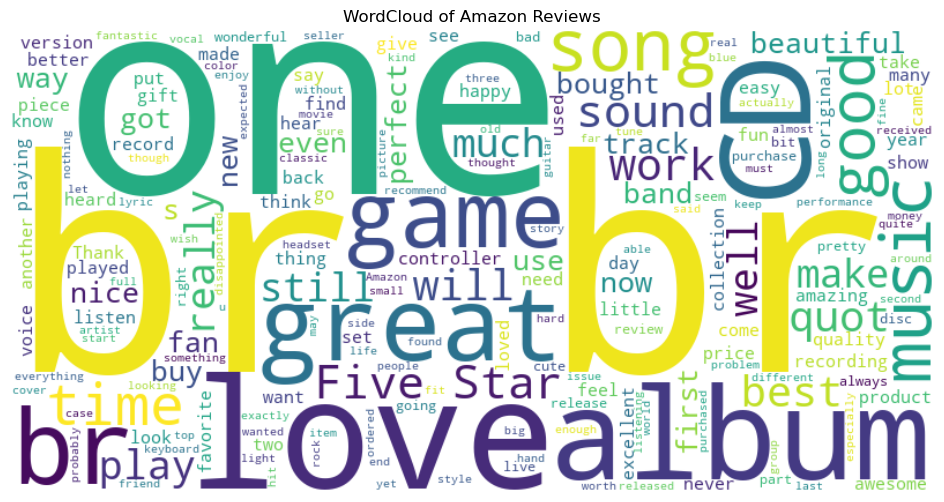

In [66]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud of Amazon Reviews")
plt.show()

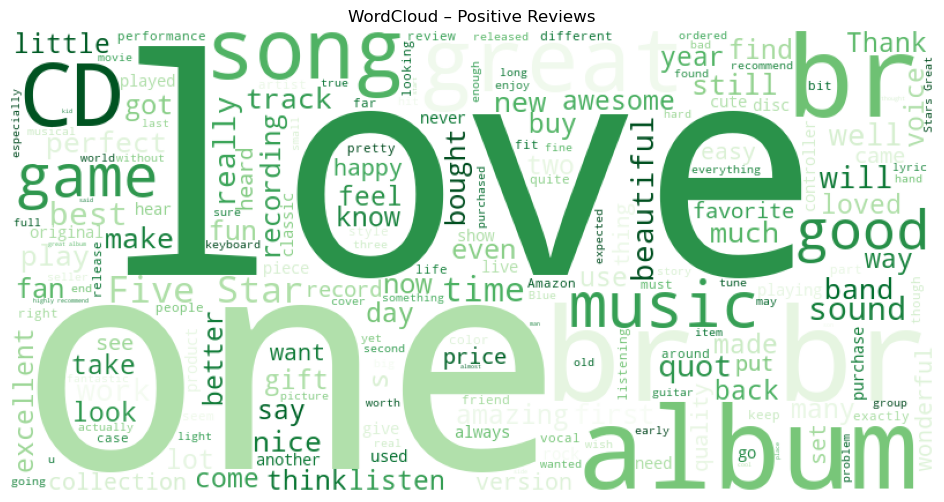

In [68]:
positive_reviews = reviews_df[reviews_df["rating"] >= 4]

positive_text = " ".join(positive_reviews["review_text"].astype(str))

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Greens"
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_pos)
plt.axis("off")
plt.title("WordCloud – Positive Reviews")
plt.show()

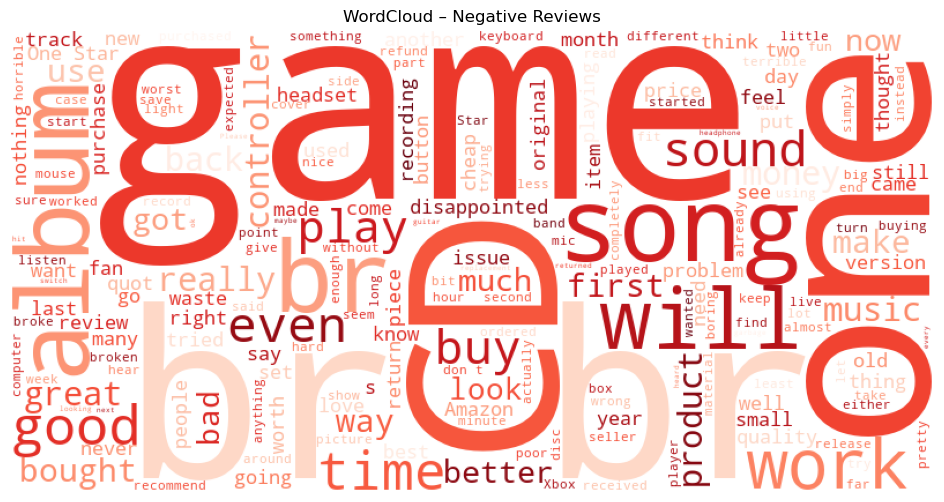

In [70]:
negative_reviews = reviews_df[reviews_df["rating"] <= 2]

negative_text = " ".join(negative_reviews["review_text"].astype(str))

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Reds"
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("WordCloud – Negative Reviews")
plt.show()